# UNet++ Training — ISIC 2018 Skin Lesion Segmentation

**Model:** UNet++ (`utils/unetpp.py`)  
**Dataset:** ISIC 2018 Challenge Task 1  
**References:**
- Paper: [UNet++: A Nested U-Net Architecture](https://arxiv.org/abs/1807.10165) — Zhou et al., 2018
- Follow-up: [UNet 3+](https://arxiv.org/abs/2004.08790) — Huang et al., 2020
- Loss functions for segmentation: [Unified Focal Loss](https://arxiv.org/abs/2102.04525) — Yeung et al., 2021
- Blog: [Metrics for Semantic Segmentation](https://towardsdatascience.com/metrics-to-evaluate-your-semantic-segmentation-model-6bcb99639aa2)
- Blog: [A Survey of Loss Functions for Semantic Segmentation](https://arxiv.org/abs/2006.14822)

---
## ⚙️ Variables to tune before training
All configurable knobs are in **Section 1 — Config**. Nothing else needs to change.

---
## Step 0 — Install dependencies

In [ ]:
!pip install torch torchvision albumentations tqdm matplotlib scikit-learn -q

---
## Step 1 — Config  ← **Change these before training**

In [2]:
import os

# ─── Paths ────────────────────────────────────────────────────────────────────
# Adjust these to match the folder layout on the training machine.
DATASET_ROOT = '../dataset/ISIC2018'
IMAGES_PATH  = os.path.join(DATASET_ROOT, 'ISIC2018_Task1-2_Training_Input')
MASKS_PATH   = os.path.join(DATASET_ROOT, 'ISIC2018_Task1_Training_GroundTruth')
SPLIT_JSON   = '../splits/dataset_split.json'   # generated by preprocessing notebook
CHECKPOINT_DIR = '../checkpoints'               # where best model weights are saved
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ─── Model ────────────────────────────────────────────────────────────────────
IN_CHANNELS      = 3      # RGB
OUT_CHANNELS     = 1      # binary mask
DEPTH            = 4      # UNet++ depth (paper default)
BASE_FILTERS     = 32     # ↑ to 64 for higher accuracy at the cost of VRAM
DEEP_SUPERVISION = False  # set True to enable deep-supervision averaging

# ─── Training ─────────────────────────────────────────────────────────────────
IMAGE_SIZE   = 256        # must match preprocessing notebook
BATCH_SIZE   = 16          # ↑ if VRAM allows (e.g. 16 or 32 on RTX 4060)
NUM_EPOCHS   = 50
LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
NUM_WORKERS   = 0         # ↑ on multi-core machines; 0 to disable multiprocessing
RANDOM_SEED  = 42
VAL_SPLIT    = 0.2        # must match preprocessing notebook

# ─── Early stopping ──────────────────────────────────────────────────────────
PATIENCE = 10             # stop if val loss doesn't improve for this many epochs

# ─── Mixed precision ─────────────────────────────────────────────────────────
# Speeds up training on Ampere+ GPUs (RTX 3xxx / 4xxx). Safe to keep True.
USE_AMP = True

print('Config loaded.')
print(f'  BATCH_SIZE   = {BATCH_SIZE}')
print(f'  BASE_FILTERS = {BASE_FILTERS}')
print(f'  NUM_EPOCHS   = {NUM_EPOCHS}')
print(f'  LEARNING_RATE= {LEARNING_RATE}')
print(f'  USE_AMP      = {USE_AMP}')

Config loaded.
  BATCH_SIZE   = 16
  BASE_FILTERS = 32
  NUM_EPOCHS   = 50
  LEARNING_RATE= 0.0001
  USE_AMP      = True


---
## Step 2 — Imports & device check

In [3]:
import sys
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.cuda.amp import GradScaler
from torch.cuda.amp import  autocast
from torch.utils.data import Dataset, DataLoader, Subset
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Add project root to path so we can import from utils/
sys.path.append('..')
from utils.Unetpp import UNetPP

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {device}')
if device.type == 'cuda':
    print(f'GPU           : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device : cuda
GPU           : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM total    : 8.6 GB


---
## Step 3 — Dataset & DataLoaders
Reuses the exact same `ISICDataset` class and split indices from the preprocessing notebook.

In [4]:
# ── ImageNet normalization (matches preprocessing) ────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Transforms ────────────────────────────────────────────────────────────────
# Augmentation is applied only during training to reduce overfitting.
# References:
#   - Albumentations paper: https://arxiv.org/abs/1809.06839
#   - Medical image augmentation survey: https://arxiv.org/abs/2010.09875
train_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.0, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2()
])


# ── Dataset class (mirrors preprocessing notebook) ───────────────────────────
class ISICDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path  = masks_path
        self.transform   = transform
        self.images = []
        for f in sorted(os.listdir(images_path)):
            if not f.endswith('.jpg'):
                continue
            mask_file = f.replace('.jpg', '_segmentation.png')
            if os.path.exists(os.path.join(masks_path, mask_file)):
                self.images.append(f)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_file  = self.images[idx]
        mask_file = img_file.replace('.jpg', '_segmentation.png')
        image = np.array(Image.open(os.path.join(self.images_path, img_file)).convert('RGB'))
        mask  = np.array(Image.open(os.path.join(self.masks_path,  mask_file)).convert('L'))
        mask  = (mask > 127).astype('float32')
        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug['image']
            mask  = aug['mask'].float().unsqueeze(0)
        return image, mask


# ── Load saved split indices ──────────────────────────────────────────────────
with open(SPLIT_JSON, 'r') as f:
    split_info = json.load(f)

train_idx = split_info['train_indices']
val_idx   = split_info['val_indices']
print(f'Loaded split → train: {len(train_idx)}  val: {len(val_idx)}')

# Wrap with transforms
train_ds = Subset(ISICDataset(IMAGES_PATH, MASKS_PATH, transform=train_transform), train_idx)
val_ds   = Subset(ISICDataset(IMAGES_PATH, MASKS_PATH, transform=val_transform),   val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Loaded split → train: 2076  val: 518
Train batches : 130
Val batches   : 33


c:\Users\PRAYAG\Desktop\daa_proj\daa-project\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


---
## Step 4 — Model, Loss, Optimizer, Scheduler

In [5]:
# ── Model ─────────────────────────────────────────────────────────────────────
model = UNetPP(
    in_channels      = IN_CHANNELS,
    out_channels     = OUT_CHANNELS,
    depth            = DEPTH,
    base_filters     = BASE_FILTERS,
    deep_supervision = DEEP_SUPERVISION,
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

# ── Loss ──────────────────────────────────────────────────────────────────────
# BCEWithLogitsLoss is standard for binary segmentation.
# Combined with Dice for better handling of class imbalance.
# Reference: https://arxiv.org/abs/2006.14822  (Loss survey)

bce_loss_fn = nn.BCEWithLogitsLoss()

def dice_loss(pred, target, smooth=1.0):
    """Differentiable Dice loss. pred is raw logits."""
    pred   = torch.sigmoid(pred)
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def combined_loss(pred, target, bce_weight=0.5):
    return bce_weight * bce_loss_fn(pred, target) + (1 - bce_weight) * dice_loss(pred, target)

# ── Optimizer ────────────────────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# ── LR Scheduler ─────────────────────────────────────────────────────────────
# ReduceLROnPlateau halves LR when val loss stalls.
# Reference: https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

# ── AMP Scaler ────────────────────────────────────────────────────────────────
scaler = GradScaler(enabled=USE_AMP)

print('\nModel, loss, optimizer, scheduler ready.')

Total params     : 8,824,289
Trainable params : 8,824,289

Model, loss, optimizer, scheduler ready.


c:\Users\PRAYAG\Desktop\daa_proj\daa-project\venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(
C:\Users\PRAYAG\AppData\Local\Temp\ipykernel_12200\1247017395.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


---
## Step 5 — Metric helpers
Dice Score and IoU (Jaccard Index) — standard for medical image segmentation.

> Reference: [Evaluation of segmentation metrics](https://arxiv.org/abs/2206.01653) — Reinke et al., 2022

In [6]:
def dice_score(pred_logits, target, threshold=0.5):
    """Dice coefficient from raw logits. Returns value in [0, 1]."""
    pred   = (torch.sigmoid(pred_logits) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return ((2. * intersection) / (pred.sum() + target.sum() + 1e-8)).item()

def iou_score(pred_logits, target, threshold=0.5):
    """Intersection-over-Union (Jaccard) from raw logits."""
    pred   = (torch.sigmoid(pred_logits) > threshold).float()
    pred   = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    union        = pred.sum() + target.sum() - intersection
    return (intersection / (union + 1e-8)).item()

print('Metrics defined: dice_score, iou_score')

Metrics defined: dice_score, iou_score


---
## Step 6 — Train & Validation loops

In [7]:
def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou  = 0.0

    loop = tqdm(loader, desc='  Train', leave=False)
    for images, masks in loop:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        optimizer.zero_grad()
        with autocast(enabled=USE_AMP):
            preds = model(images)
            loss  = combined_loss(preds, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        running_dice += dice_score(preds.detach(), masks)
        running_iou  += iou_score(preds.detach(),  masks)
        loop.set_postfix(loss=f'{loss.item():.4f}')

    n = len(loader)
    return running_loss / n, running_dice / n, running_iou / n


@torch.no_grad()
def validate(model, loader):
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou  = 0.0

    loop = tqdm(loader, desc='  Val  ', leave=False)
    for images, masks in loop:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device,  non_blocking=True)

        with autocast(enabled=USE_AMP):
            preds = model(images)
            loss  = combined_loss(preds, masks)

        running_loss += loss.item()
        running_dice += dice_score(preds, masks)
        running_iou  += iou_score(preds,  masks)

    n = len(loader)
    return running_loss / n, running_dice / n, running_iou / n

print('Train/val loops defined.')

Train/val loops defined.


---
## Step 7 — Training loop with early stopping & checkpointing

In [8]:
history = {
    'train_loss': [], 'val_loss': [],
    'train_dice': [], 'val_dice': [],
    'train_iou' : [], 'val_iou' : [],
    'lr'        : [],
}

best_val_loss    = float('inf')
epochs_no_improve = 0
checkpoint_path  = os.path.join(CHECKPOINT_DIR, 'unetpp_best.pth')

print(f'Training for up to {NUM_EPOCHS} epochs  (patience={PATIENCE})')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()

    tr_loss, tr_dice, tr_iou = train_one_epoch(model, train_loader, optimizer, scaler)
    vl_loss, vl_dice, vl_iou = validate(model, val_loader)

    scheduler.step(vl_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # ── Log ──────────────────────────────────────────────────────────────────
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_dice'].append(tr_dice)
    history['val_dice'].append(vl_dice)
    history['train_iou'].append(tr_iou)
    history['val_iou'].append(vl_iou)
    history['lr'].append(current_lr)

    elapsed = time.time() - t0
    print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | '
          f'Loss  tr={tr_loss:.4f}  vl={vl_loss:.4f} | '
          f'Dice  tr={tr_dice:.4f}  vl={vl_dice:.4f} | '
          f'IoU   tr={tr_iou:.4f}  vl={vl_iou:.4f} | '
          f'LR={current_lr:.2e} | {elapsed:.1f}s')

    # ── Checkpoint ───────────────────────────────────────────────────────────
    if vl_loss < best_val_loss:
        best_val_loss = vl_loss
        epochs_no_improve = 0
        torch.save({
            'epoch'         : epoch,
            'model_state'   : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_loss'      : vl_loss,
            'val_dice'      : vl_dice,
            'val_iou'       : vl_iou,
            'config': {
                'IN_CHANNELS': IN_CHANNELS, 'OUT_CHANNELS': OUT_CHANNELS,
                'DEPTH': DEPTH, 'BASE_FILTERS': BASE_FILTERS,
                'DEEP_SUPERVISION': DEEP_SUPERVISION,
                'IMAGE_SIZE': IMAGE_SIZE,
            }
        }, checkpoint_path)
        print(f'  ✅ Checkpoint saved  (val_loss={vl_loss:.4f})')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f'\n⏹  Early stopping triggered after {epoch} epochs.')
            break

print('\nTraining complete.')
print(f'Best val loss : {best_val_loss:.4f}')
print(f'Checkpoint    : {checkpoint_path}')

Training for up to 50 epochs  (patience=10)


  Train:   0%|          | 0/130 [00:00<?, ?it/s]C:\Users\PRAYAG\AppData\Local\Temp\ipykernel_12200\3605173905.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
  Val  :   0%|          | 0/33 [00:00<?, ?it/s]                        C:\Users\PRAYAG\AppData\Local\Temp\ipykernel_12200\3605173905.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 001/50 | Loss  tr=0.5594  vl=0.4792 | Dice  tr=0.6330  vl=0.7374 | IoU   tr=0.4763  vl=0.5888 | LR=1.00e-04 | 386.2s
  ✅ Checkpoint saved  (val_loss=0.4792)


Epoch 002/50 | Loss  tr=0.4558  vl=0.4225 | Dice  tr=0.7715  vl=0.8204 | IoU   tr=0.6332  vl=0.6983 | LR=1.00e-04 | 365.2s
  ✅ Checkpoint saved  (val_loss=0.4225)


Epoch 003/50 | Loss  tr=0.4109  vl=0.3862 | Dice  tr=0.8058  vl=0.8196 | IoU   tr=0.6789  vl=0.6976 | LR=1.00e-04 | 347.8s
  ✅ Checkpoint saved  (val_loss=0.3862)


...

Epoch 046/50 | Loss  tr=0.1189  vl=0.1479 | Dice  tr=0.9001  vl=0.8789 | IoU   tr=0.8198  vl=0.7874 | LR=1.00e-04 | 351.4s
  ✅ Checkpoint saved  (val_loss=0.1479)


Epoch 047/50 | Loss  tr=0.1135  vl=0.1500 | Dice  tr=0.9053  vl=0.8780 | IoU   tr=0.8285  vl=0.7862 | LR=1.00e-04 | 346.4s


Epoch 048/50 | Loss  tr=0.1194  vl=0.1526 | Dice  tr=0.8988  vl=0.8742 | IoU   tr=0.8178  vl=0.7799 | LR=1.00e-04 | 344.5s


Epoch 049/50 | Loss  tr=0.1155  vl=0.1505 | Dice  tr=0.9022  vl=0.8787 | IoU   tr=0.8239  vl=0.7870 | LR=1.00e-04 | 350.6s


Epoch 050/50 | Loss  tr=0.1150  vl=0.1517 | Dice  tr=0.9025  vl=0.8749 | IoU   tr=0.8239  vl=0.7808 | LR=1.00e-04 | 356.0s

Training complete.
Best val loss : 0.1479
Checkpoint    : ../checkpoints\unetpp_best.pth


---
## Step 8 — Training curves

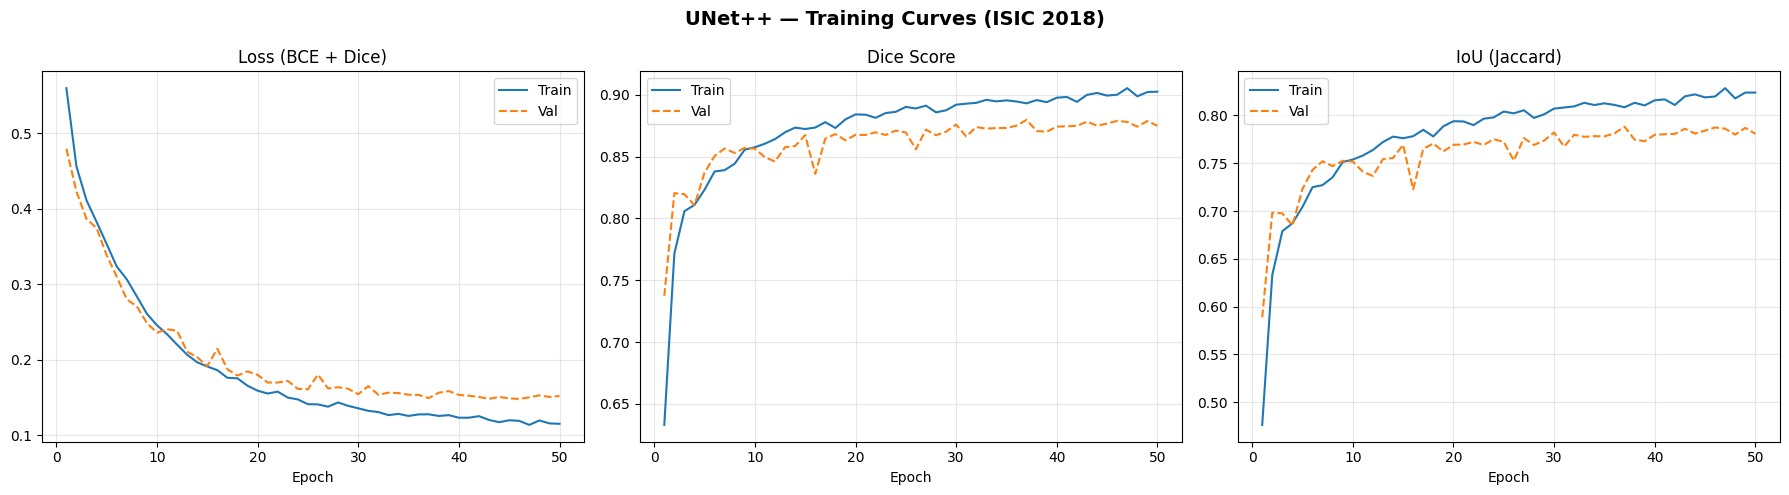

Saved → training_curves.png


In [9]:
os.makedirs('../output', exist_ok=True)

epochs_ran = list(range(1, len(history['train_loss']) + 1))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('UNet++ — Training Curves (ISIC 2018)', fontsize=14, fontweight='bold')

for ax, metric, title in zip(
    axes,
    [('train_loss', 'val_loss'), ('train_dice', 'val_dice'), ('train_iou', 'val_iou')],
    ['Loss (BCE + Dice)', 'Dice Score', 'IoU (Jaccard)']
):
    ax.plot(epochs_ran, history[metric[0]], label='Train')
    ax.plot(epochs_ran, history[metric[1]], label='Val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../output/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

---
## Step 9 — Load best checkpoint & evaluate on validation set

In [10]:
checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state'])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"  val_loss = {checkpoint['val_loss']:.4f}")
print(f"  val_dice = {checkpoint['val_dice']:.4f}")
print(f"  val_iou  = {checkpoint['val_iou']:.4f}")

# Full pass on validation set
final_loss, final_dice, final_iou = validate(model, val_loader)
print(f'\n── Final Validation Metrics ──')
print(f'  Loss : {final_loss:.4f}')
print(f'  Dice : {final_dice:.4f}')
print(f'  IoU  : {final_iou:.4f}')

C:\Users\PRAYAG\AppData\Local\Temp\ipykernel_12200\977739468.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device

Loaded checkpoint from epoch 46
  val_loss = 0.1479
  val_dice = 0.8789
  val_iou  = 0.7874


  Val  :   0%|          | 0/33 [00:00<?, ?it/s]C:\Users\PRAYAG\AppData\Local\Temp\ipykernel_12200\3605173905.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
                                                        


── Final Validation Metrics ──
  Loss : 0.1479
  Dice : 0.8789
  IoU  : 0.7874


---
## Step 10 — Qualitative predictions on validation images

C:\Users\PRAYAG\AppData\Local\Temp\ipykernel_12200\1659274669.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


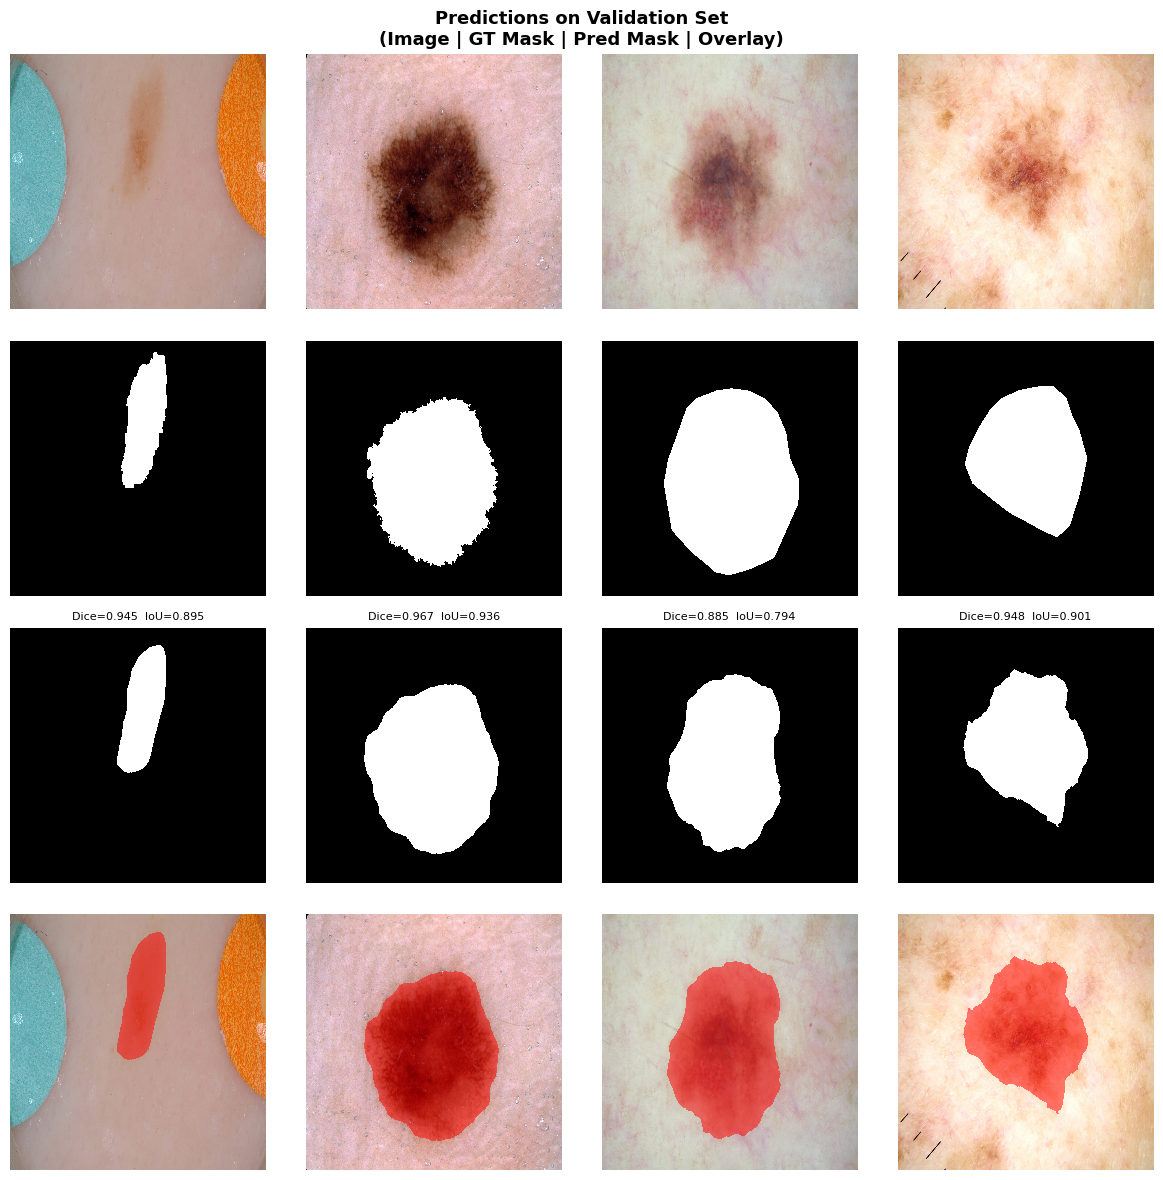

Saved → predictions.png


In [11]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def denormalize(t):
    img = t.permute(1, 2, 0).cpu().numpy()
    return np.clip(img * STD + MEAN, 0, 1)

model.eval()
images, masks = next(iter(val_loader))
images = images.to(device)

with torch.no_grad():
    with autocast(enabled=USE_AMP):
        preds = torch.sigmoid(model(images)).cpu()

n   = min(4, images.shape[0])
fig, axes = plt.subplots(4, n, figsize=(n * 3, 12))
fig.suptitle('Predictions on Validation Set\n(Image | GT Mask | Pred Mask | Overlay)',
             fontsize=13, fontweight='bold')

row_titles = ['Input Image', 'Ground Truth', 'Predicted Mask', 'Overlay']
for row_ax, title in zip(axes, row_titles):
    row_ax[0].set_ylabel(title, fontsize=10, rotation=90, labelpad=10)

for i in range(n):
    img_disp   = denormalize(images[i].cpu())
    gt_disp    = masks[i].squeeze().numpy()
    pred_disp  = (preds[i].squeeze().numpy() > 0.5).astype(float)

    overlay = img_disp.copy()
    overlay[pred_disp > 0.5] = (
        overlay[pred_disp > 0.5] * 0.5 + np.array([1.0, 0.0, 0.0]) * 0.5
    )

    d = dice_score(model(images[i:i+1].to(device)), masks[i:i+1].to(device))
    j = iou_score( model(images[i:i+1].to(device)), masks[i:i+1].to(device))

    axes[0, i].imshow(img_disp);                       axes[0, i].axis('off')
    axes[1, i].imshow(gt_disp,  cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')
    axes[2, i].imshow(pred_disp, cmap='gray', vmin=0, vmax=1)
    axes[2, i].set_title(f'Dice={d:.3f}  IoU={j:.3f}', fontsize=8)
    axes[2, i].axis('off')
    axes[3, i].imshow(overlay);                        axes[3, i].axis('off')

plt.tight_layout()
plt.savefig('../output/predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → predictions.png')

---
## Step 11 — Save training history as JSON

In [12]:
history_path = os.path.join(CHECKPOINT_DIR, 'training_history.json')
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f'History saved → {history_path}')

print('\n' + '=' * 55)
print('   TRAINING COMPLETE — SUMMARY')
print('=' * 55)
print(f'  Epochs trained   : {len(history["train_loss"])}')
print(f'  Best val loss    : {best_val_loss:.4f}')
print(f'  Final val Dice   : {final_dice:.4f}')
print(f'  Final val IoU    : {final_iou:.4f}')
print(f'  Checkpoint       : {checkpoint_path}')
print('=' * 55)

History saved → ../checkpoints\training_history.json

   TRAINING COMPLETE — SUMMARY
  Epochs trained   : 50
  Best val loss    : 0.1479
  Final val Dice   : 0.8789
  Final val IoU    : 0.7874
  Checkpoint       : ../checkpoints\unetpp_best.pth
